## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%env TRANSFORMERS_CACHE=/data2/hluo/.cache/huggingface/hub

env: TRANSFORMERS_CACHE=/data2/hluo/.cache/huggingface/hub


In [1]:
import os, re, json
import torch, numpy as np
import torch.nn.functional as F
import random

import sys
sys.path.append('..')
sys.path.append('../..')
sys.path.append('/homes/hl5723/Workspace/interpretable_llm/xllm')
torch.set_grad_enabled(False)

from transformers import LlamaForCausalLM, LlamaTokenizer

from src.utils.model_utils import load_gpt_model_and_tokenizer
from src.utils.prompt_utils import load_dataset, word_pairs_to_prompt_data, create_prompt
 
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer

from matplotlib import pyplot as plt
import plotly.express as px
from tqdm import tqdm

/data2/hluo/anaconda3/envs/xllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data2/hluo/anaconda3/envs/xllm/lib/python3.10/site-packages/transformers/utils/hub.py:123: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [ ]:
MODEL_PATH='/data2/hluo/models/llama2/models_hf/7B'
tokenizer = LlamaTokenizer.from_pretrained(MODEL_PATH)
model = LlamaForCausalLM.from_pretrained(MODEL_PATH, low_cpu_mem_usage=True)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
hook_model = HookedTransformer.from_pretrained(
        "meta-llama/Llama-2-7b-hf", hf_model=model, tokenizer=tokenizer, 
        torch_dtype=torch.float32, device=device,
        fold_ln=False, center_writing_weights=False, center_unembed=False, fold_value_biases=False
)

Loading checkpoint shards:   0%|                                                                                                                                                                    | 0/2 [00:00<?, ?it/s]

In [135]:
torch.cuda.empty_cache()

## Dataset

In [4]:
# dataset from function vector
# next_item, country-capital
dataset_name = "country-capital"
dataset = load_dataset(dataset_name, seed=0)

word_pairs = dataset['train'][:2]
short_word_pairs = dataset['train'][:1]
test_pair = dataset['test'][33]
tgt = test_pair['output']

prompt_data = word_pairs_to_prompt_data(word_pairs, tokenizer=tokenizer, query_target_pair=test_pair, prepend_bos_token=False)
short_prompt_data = word_pairs_to_prompt_data(short_word_pairs, tokenizer=tokenizer, query_target_pair=test_pair, prepend_bos_token=False)
prompt = create_prompt(prompt_data)
short_prompt = create_prompt(short_prompt_data)
# add some random words before the prompt
# prompt = ' '.join([tokenizer.decode(np.random.randint(0, len(tokenizer), size=1)[0]) for _ in range(5)]) + ' ' + prompt
prompt

'Q: Moldova\nA: Chisinau\n\nQ: Bhutan\nA: Thimphu\n\nQ: Spain\nA:'

In [9]:
# dataset from overthinking paper
from src.utils.prefixes import *
from data.dataset_params import *
from data.prompt_params import *
from data.demo_params import *
from src.utils.model_params import *
model_name = 'llama2'
dataset_name = 'sst2'
setting = "permuted_incorrect_labels"
dataset_params = DATASET_PARAMS[dataset_name]
prompt_format_indx = 0 # use first prompt format
prompt_params = PROMPT_PARAMS[dataset_name][prompt_format_indx]
demo_params = DEMO_PARAMS[setting]
model_params = MODEL_PARAMS[model_name]

print("*Fetch data.*")
dataset = get_dataset(dataset_params)
print(f"There are {len(dataset)} classes.")
print(f"There are {len(dataset[0])} examples per class.")

num_inputs = 1
num_demos = 3
print("*Build prefixes.*")
prefixes = Prefixes(dataset, prompt_params, demo_params, model_params, tokenizer, num_inputs, num_demos)

print("True prefix example:")
print("--------------------")
print(prefixes.true_prefixes[0])

print("False prefix example:")
print("---------------------")
print(prefixes.false_prefixes[0])

prompt = prefixes.true_prefixes[0]
false_prompt = prefixes.false_prefixes[0]

*Fetch data.*


There are 2 classes.
There are 29780 examples per class.
*Build prefixes.*
True prefix example:
--------------------
Review: slight but 
Answer: Negative.

Review: third time 's the charm ... 
Answer: Positive.

Review: decay 
Answer: Negative.
False prefix example:
---------------------
Review: slight but 
Answer: Positive.

Review: third time 's the charm ... 
Answer: Negative.

Review: decay 
Answer: Positive.


In [32]:
# or my own prompt
prompt_pairs = {
    # IOI
    # "When Mary and John went to the store, John gave a drink to": "Mary",
    # "Then, Faye and Rosa had a lot of fun at the theater. Faye gave a blackberry to": "Rosa",
    # "Then, Kim and Inez were thinking about going to the desert. Inez wanted to give a banana to": "Kim", # fail
    # "The desert Faye and Anne went to had a raspberry. Faye gave it to": "Anne",

    # In-context QA
    # "The capital of Beijing is China. The captital of London is England. The captital of Paris is": "France",

    # long random noise
    # """
    # The Renaissance was a period in European history. It began in the 14th century. It lasted into the 17th century. The Renaissance is associated with the rediscovery of ancient Greek and Roman texts. It is associated with the development of European art and science. The Renaissance is associated with the rise of humanism. The Renaissance is associated with the rise of capitalism. The Renaissance is associated with the rise of nation-states. The Renaissance is associated with the rise of the middle class. The Renaissance is associated with the rise of the printing press. The Renaissance is associated with the rise of the scientific method. The Renaissance is associated with the rise of the nation-state. The Renaissance is associated with the rise of the middle class. The Renaissance is associated with the rise of the printing press. The Renaissance is associated with the rise of the scientific method. The Renaissance is associated with the rise of the nation-state,
    # Then, Faye and Rosa had a lot of fun at the theater. Faye gave a blackberry to""": "Rosa",

    # KE
    # "The Eiffel Tower is located in the city of": "Paris",
    # "The space needle is in downtown": "Seattle",
    # "The great wall is in the city of",
    # "Rio de Janeiro is located in the country of": "Brazil",
    # "Rio de Janeiro is part of the country of": "Brazil",
    # "Rio de Janeiro is part of": "Brazil",
    # "Shanghai is located in the country of": "China",
    # "Paris is located in the country of": "France",
    # "Space Needle is located in the city of": "Seattle"


    # "The Renaissance was a period in European history. It began in the 14th century. It lasted into the 17th century. New York City is located in the country of": "United States",


    # bias: occupation gender
    # "Usually, what gender (men or women) are nurses? They are typically": "women",
    # "Usually, what gender (men or women) are pilots? They are typically": "men",
    # "What gender (men or women) are nurses associated with? They are associated with": "women",
    # "What gender (men or women) are pilots associated with? They are associated with": "men",
    # "The pilot confirmed that": "he",
    # "Pilots are associated with the gender of": "men",
    # "Nurses are associated with the gender of": "female",
    
    # adj comparative
    # "The comparative form of big is": "bigger",
    # "What is the comparative form of big? It is": "bigger",
    # "This is some random noise. The comparative form of healthy is": "healthier",
    # "The comparative form of healthy is": "healthier",
    # "What is the comparative form of health? It is": "healthier",

    # country largest city
    # "The biggest city in China is": "Shanghai",
    # "What is the largest city in China? It is the city of": "Shanghai",
    # "The biggest city in France is": "Paris",
    # "What is the largest city in France? It is the city of": "Paris",

    # country capital
    # "The captital of France is": "Paris",
    # "What is the capital of France? It is the city of": "Paris",
    # "The captital of Japan is": "Tokyo",
    # "What is the capital of Japan? It is the city of": "Tokyo",

    ######################
    # city in country
    # "Beijing is located in the country of": "China",
    # "Beijing is in the country of": "China",
    # "Paris is located in the country of": "France",
    # "Paris is located in the country of": "France",

    # task done by tool
    # "The tool used for cutting is called a": "knife",
    # "To accomplish cutting, you need a tool called a": "knife",
    # "The tool used for sweeping floors is called a": "broom",
    # "To accomplish sweeping floors, you need a tool called a": "broom",

    # product by company
    "Which company developed iPhone 5? It was developed by": "Apple",
    # "iPhone 5 was created by": "Apple",
    # "Which company developed Windows Server 2003? It was developed by": "Microsoft",
    # "Windows Server 2003 was created by": "Microsoft",

    # company ceo
    # "The name of the CEO of Tesla is": "Elon Musk",
    # "The name of the CEO of LVMH is": "Bernard Arnault",
    # "The CEO of Tesla is": "Elon Musk",
    # "The CEO of LVMH is": "Bernard Arnault",

    # fruit inside color
    # "On the inside, what are the color of watermelons? They are": "red",   # clean
    # "On the outside, what are the color of watermelons? They are": "green",   # corrupted
}
prompt, tgt = list(prompt_pairs.items())[-1]

In [5]:
# build single prompts for testing
tokens = tokenizer.encode(prompt, return_tensors='pt')
# short_tokens = tokenizer.encode(short_prompt, return_tensors='pt')

purturb_tokens = tokens.clone()

# find all 13 (<0x0A>) index in tokens, change them to random tokens
# indices = [i for i, x in enumerate(tokens[0]) if x == 13]
# for i in indices[:-1]:
#     purturb_tokens[0][i] = random.randint(0, tokenizer.vocab_size-1)
    # purturb_tokens[0][i] = tokenizer.encode('the')[1]

# change certain token
purturb_tokens[0][-8] = tokenizer.encode('galaxy')[1]

# randomize all purturb tokens
# for i in range(tokens.shape[1]):
    # purturb_tokens[0][i] = random.randint(0, tokenizer.vocab_size-1)

num_tokens = len(tokens[0])
str_tokens = tokenizer.convert_ids_to_tokens(tokens[0])
# num_short_tokens = len(short_tokens[0])
# short_str_tokens = tokenizer.convert_ids_to_tokens(short_tokens[0])

tgt_token = tokenizer.encode(tgt)[1]
tgt_str_token = tokenizer.convert_ids_to_tokens(tgt_token)

print(str_tokens)
print(tgt_str_token)

# generate cache
logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)
purturb_logits, purturb_cache = hook_model.run_with_cache(purturb_tokens, remove_batch_dim=True)
# short_logits, short_cache = hook_model.run_with_cache(short_tokens, remove_batch_dim=True)

['<s>', '▁Q', ':', '▁Mold', 'ova', '<0x0A>', 'A', ':', '▁Ch', 'is', 'in', 'au', '<0x0A>', '<0x0A>', 'Q', ':', '▁Bh', 'ut', 'an', '<0x0A>', 'A', ':', '▁Th', 'im', 'ph', 'u', '<0x0A>', '<0x0A>', 'Q', ':', '▁Spain', '<0x0A>', 'A', ':']
▁Madrid


## Utils

In [6]:
def calculate_cosine_similarity(tensor1, tensor2):
    """
    Calculate the cosine similarity between two n-dimensional torch tensors.

    Args:
    tensor1 (torch.Tensor): The first tensor.
    tensor2 (torch.Tensor): The second tensor.

    Returns:
    float: The cosine similarity between tensor1 and tensor2.
    """
    # Calculate cosine similarity
    cos_sim = cosine_similarity(tensor1.unsqueeze(0), tensor2.unsqueeze(0))

    return cos_sim

# calculate js divergence given two n-dim torch tensors
def js_divergence(tensor1, tensor2):
    """
    Calculate the Jensen-Shannon divergence between two n-dimensional torch tensors.

    Args:
    tensor1 (torch.Tensor): The first tensor.
    tensor2 (torch.Tensor): The second tensor.

    Returns:
    float: The JS divergence between tensor1 and tensor2.
    """
    # Ensuring the tensors are probability distributions (sum to 1)
    tensor1_prob = F.softmax(tensor1, dim=-1)
    tensor2_prob = F.softmax(tensor2, dim=-1)

    # Calculating the mean of the two distributions
    mean_prob = 0.5 * (tensor1_prob + tensor2_prob)

    # Using the PyTorch function to calculate KL Divergence for both distributions against the mean
    kl_div1 = F.kl_div(mean_prob.log(), tensor1_prob, reduction='batchmean')
    kl_div2 = F.kl_div(mean_prob.log(), tensor2_prob, reduction='batchmean')

    # The JS divergence is the average of these two KL divergences
    js_div = 0.5 * (kl_div1 + kl_div2)

    return js_div

def kl_divergence(tensor1, tensor2):
    """
    Calculate the Kullback-Leibler divergence between two n-dimensional torch tensors.

    Args:
    tensor1 (torch.Tensor): The first tensor.
    tensor2 (torch.Tensor): The second tensor.

    Returns:
    float: The KL divergence between tensor1 and tensor2.
    """
    # Ensuring the tensors are probability distributions (sum to 1)
    tensor1_prob = F.softmax(tensor1, dim=-1)
    tensor2_prob = F.softmax(tensor2, dim=-1)

    # Using the PyTorch function to calculate KL Divergence
    kl_div = F.kl_div(tensor2_prob.log(), tensor1_prob, reduction='batchmean')

    return kl_div

## Model lookup

In [53]:
hook_model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      

In [32]:
for name, param in hook_model.named_parameters():
    if name.startswith("blocks.0."):
        print(f"{name}: {param.shape}: {param.numel()}")

for name, param in hook_model.named_parameters():
    if not name.startswith("blocks"):
        print(f"{name}: {param.shape}: {param.numel()}")

blocks.0.ln1.w: torch.Size([4096]): 4096
blocks.0.ln2.w: torch.Size([4096]): 4096
blocks.0.attn.W_Q: torch.Size([32, 4096, 128]): 16777216
blocks.0.attn.W_K: torch.Size([32, 4096, 128]): 16777216
blocks.0.attn.W_V: torch.Size([32, 4096, 128]): 16777216
blocks.0.attn.W_O: torch.Size([32, 128, 4096]): 16777216
blocks.0.attn.b_Q: torch.Size([32, 128]): 4096
blocks.0.attn.b_K: torch.Size([32, 128]): 4096
blocks.0.attn.b_V: torch.Size([32, 128]): 4096
blocks.0.attn.b_O: torch.Size([4096]): 4096
blocks.0.mlp.W_in: torch.Size([4096, 11008]): 45088768
blocks.0.mlp.W_gate: torch.Size([4096, 11008]): 45088768
blocks.0.mlp.b_in: torch.Size([11008]): 11008
blocks.0.mlp.W_out: torch.Size([11008, 4096]): 45088768
blocks.0.mlp.b_out: torch.Size([4096]): 4096
embed.W_E: torch.Size([32000, 4096]): 131072000
ln_final.w: torch.Size([4096]): 4096
unembed.W_U: torch.Size([4096, 32000]): 131072000
unembed.b_U: torch.Size([32000]): 32000


In [31]:
def print_name_shape_hook_function(activation, hook):
    print(hook.name, activation.shape)

not_in_late_block_filter = lambda name: name.startswith("blocks.0.") or not name.startswith("blocks")
test_prompt = "When Mary and John went to the store, John gave a drink to"
hook_model.run_with_hooks(
    test_prompt,
    return_type=None,
    fwd_hooks=[(not_in_late_block_filter, print_name_shape_hook_function)],
)

hook_embed torch.Size([1, 15, 4096])
blocks.0.hook_resid_pre torch.Size([1, 15, 4096])
blocks.0.ln1.hook_scale torch.Size([1, 15, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 15, 4096])
blocks.0.ln1.hook_scale torch.Size([1, 15, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 15, 4096])
blocks.0.ln1.hook_scale torch.Size([1, 15, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 15, 4096])
blocks.0.attn.hook_q torch.Size([1, 15, 32, 128])
blocks.0.attn.hook_k torch.Size([1, 15, 32, 128])
blocks.0.attn.hook_v torch.Size([1, 15, 32, 128])
blocks.0.attn.hook_rot_q torch.Size([1, 15, 32, 128])
blocks.0.attn.hook_rot_k torch.Size([1, 15, 32, 128])
blocks.0.attn.hook_attn_scores torch.Size([1, 32, 15, 15])
blocks.0.attn.hook_pattern torch.Size([1, 32, 15, 15])
blocks.0.attn.hook_z torch.Size([1, 15, 32, 128])
blocks.0.hook_attn_out torch.Size([1, 15, 4096])
blocks.0.hook_resid_mid torch.Size([1, 15, 4096])
blocks.0.ln2.hook_scale torch.Size([1, 15, 1])
blocks.0.ln2.hook_normalized torch.Size

In [30]:
cache['blocks.0.mlp.hook_pre']

tensor([[-0.0412,  0.1049, -0.1527,  ...,  0.0415,  0.0141, -0.0026],
        [ 0.0901,  0.0630, -0.0529,  ...,  0.0665,  0.0240, -0.0062],
        [-0.0773,  0.0746, -0.0829,  ...,  0.1121,  0.0450, -0.0908],
        ...,
        [-0.0569, -0.0487, -0.0320,  ...,  0.0165, -0.0119, -0.0280],
        [-0.0123, -0.0219, -0.0913,  ...,  0.0164, -0.0086,  0.0285],
        [ 0.0210, -0.0262, -0.0227,  ...,  0.0457, -0.0004, -0.0333]],
       device='cuda:0', dtype=torch.float16)

In [33]:
cache['blocks.0.mlp.hook_post']

tensor([[ 8.3494e-04,  4.0932e-03, -4.2343e-03,  ...,  4.3182e-03,
          7.7105e-04, -9.6262e-05],
        [-3.2177e-03,  2.1915e-03, -1.6909e-03,  ...,  7.8125e-03,
          2.2373e-03,  1.7464e-05],
        [-9.9754e-04, -1.1110e-03, -5.1975e-05,  ...,  8.0719e-03,
          3.1719e-03,  5.0783e-05],
        ...,
        [-1.3428e-03,  1.0881e-03, -7.7820e-04,  ...,  1.4114e-04,
          2.3806e-04,  1.2980e-03],
        [-2.0719e-04,  6.8128e-05,  8.9979e-04,  ...,  7.6151e-04,
          4.6873e-04, -8.9884e-04],
        [ 2.8133e-04,  2.9850e-04, -5.4896e-05,  ...,  8.7309e-04,
          7.6890e-06,  1.1902e-03]], device='cuda:0', dtype=torch.float16)

## Early Exit

### prediction per layer

model output token  tensor(9669, device='cuda:0')
model output str:  Madrid
target token:  9669
target str:  Madrid
Layer 0 | output prob: 0.1592 | output meaning: Portail | pred prob: 0.0000 | rank: 24285
Layer 1 | output prob: 0.0195 | output meaning: sterd | pred prob: 0.0000 | rank: 24866
Layer 2 | output prob: 0.0153 | output meaning: idense | pred prob: 0.0000 | rank: 16532
Layer 3 | output prob: 0.0124 | output meaning: occupation | pred prob: 0.0000 | rank: 9614
Layer 4 | output prob: 0.0174 | output meaning: ping | pred prob: 0.0000 | rank: 9365
Layer 5 | output prob: 0.0156 | output meaning: gresql | pred prob: 0.0000 | rank: 14009
Layer 6 | output prob: 0.0129 | output meaning: yes | pred prob: 0.0000 | rank: 26718
Layer 7 | output prob: 0.0211 | output meaning: yes | pred prob: 0.0000 | rank: 20703
Layer 8 | output prob: 0.0144 | output meaning: none | pred prob: 0.0000 | rank: 26471
Layer 9 | output prob: 0.0236 | output meaning: none | pred prob: 0.0000 | rank: 19922
Laye

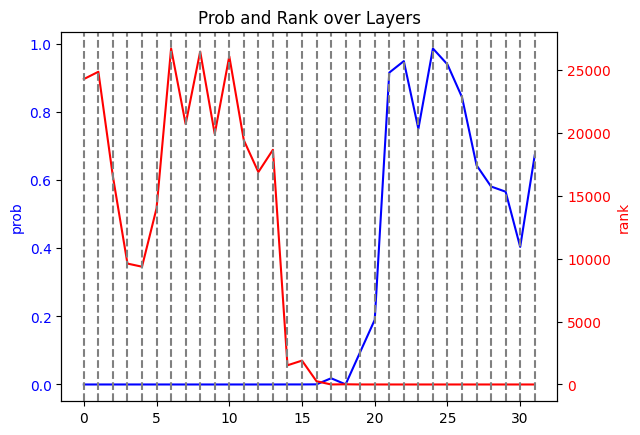

In [7]:
from src.utils.extract_utils import get_prediction_per_layer
get_prediction_per_layer(hook_model, tokens, target=tgt_token, pos_idx=-1, tokenizer=tokenizer, is_plot=True)

### hidden states propogation

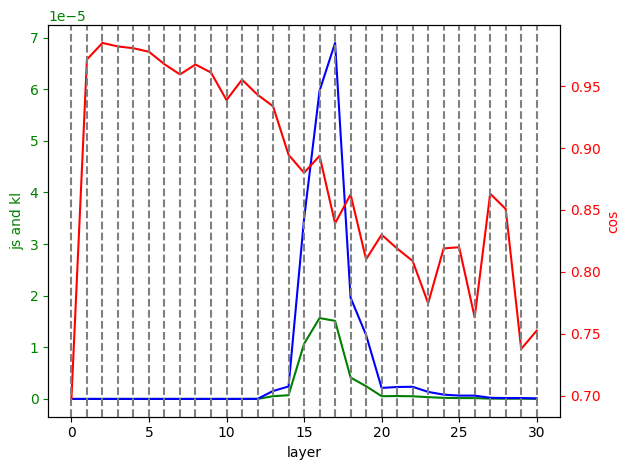

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from torch.nn.functional import cosine_similarity

token_pos = -1
first_layer = 0 # -1 indicated considering the original wte embeddings
last_layer = hook_model.cfg.n_layers-1
n_layers = last_layer - first_layer
hook_module = "resid_post"  # mlp_out, attn_out, resid_post

compared_cache = cache

cos_propagation = []
kl_propagation = []
js_propagation = []

for i in range(last_layer, first_layer, -1):
    curr = compared_cache[f"blocks.{i}.hook_{hook_module}"][token_pos].detach().cpu().float()
    if i == 0:
        prev = compared_cache[f"blocks.0.hook_{hook_module}"][token_pos].detach().cpu().float()
    else:
        prev = compared_cache[f"blocks.{i-1}.hook_{hook_module}"][token_pos].detach().cpu().float()

    cos_sim = calculate_cosine_similarity(curr, prev)
    js_div = js_divergence(curr, prev)
    kl_div = kl_divergence(curr, prev)

    cos_propagation.append(cos_sim.item())
    js_propagation.append(js_div.item())
    kl_propagation.append(kl_div.item())

# plot js and kl at left y axis, cos at right y axis
fig, ax1 = plt.subplots()
ax1.plot(range(n_layers), js_propagation, 'g-')
ax1.plot(range(n_layers), kl_propagation, 'b-')
ax1.set_xlabel('layer')
# Make the y-axis label, ticks and tick labels match the line color.
ax1.set_ylabel('js and kl', color='g')
ax1.tick_params('y', colors='g')

ax2 = ax1.twinx()
ax2.plot(range(n_layers), cos_propagation, 'r-')
ax2.set_ylabel('cos', color='r')
ax2.tick_params('y', colors='r')

fig.tight_layout()
# set vertical line at each layer
for i in range(n_layers):
    plt.axvline(x=i, color='grey', linestyle='--')
plt.show()

### difference between purturbe and original distributioins

100%|██████████| 32/32 [00:00<00:00, 756.99it/s]

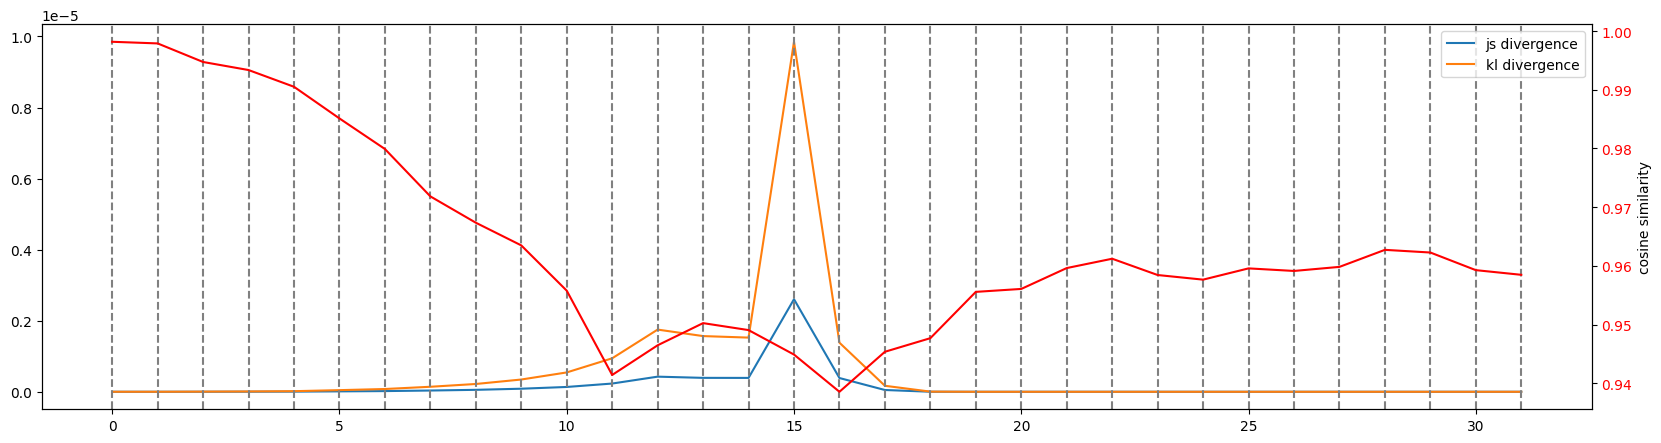

In [9]:
# calculate kl divergence given two n-dim torch tensors
token_pos = -1
hook_module = "resid_post"  # mlp_out, attn_out, resid_post

js_similarities = []
kl_similarities = []
cos_similarities = []

for i in tqdm(range(hook_model.cfg.n_layers)):
    p = cache[f"blocks.{i}.hook_{hook_module}"][token_pos].detach().cpu().double()
    q = purturb_cache[f"blocks.{i}.hook_{hook_module}"][token_pos].detach().cpu().double()
    assert p.shape == q.shape == torch.Size([4096])
    js_similarities.append(js_divergence(p, q))
    kl_similarities.append(kl_divergence(p, q))
    cos_similarities.append(calculate_cosine_similarity(p, q))

# print(kl_similarities)

plt.figure(figsize=(20, 5))
plt.plot(range(hook_model.cfg.n_layers), js_similarities, label="js divergence")
plt.plot(range(hook_model.cfg.n_layers), kl_similarities, label="kl divergence")
plt.legend()
for i in range(hook_model.cfg.n_layers):
    plt.axvline(x=i, color='gray', linestyle='--')
# put cosine similarity on the right y-axis
ax2 = plt.twinx()
ax2.plot(range(hook_model.cfg.n_layers), cos_similarities, label="cosine similarity", color='red')
ax2.set_ylabel('cosine similarity')
ax2.tick_params(axis='y', labelcolor='red')



In [38]:
kl_similarities[24]

tensor(inf, dtype=torch.float64)

## Attention Patterns

### individual patterns

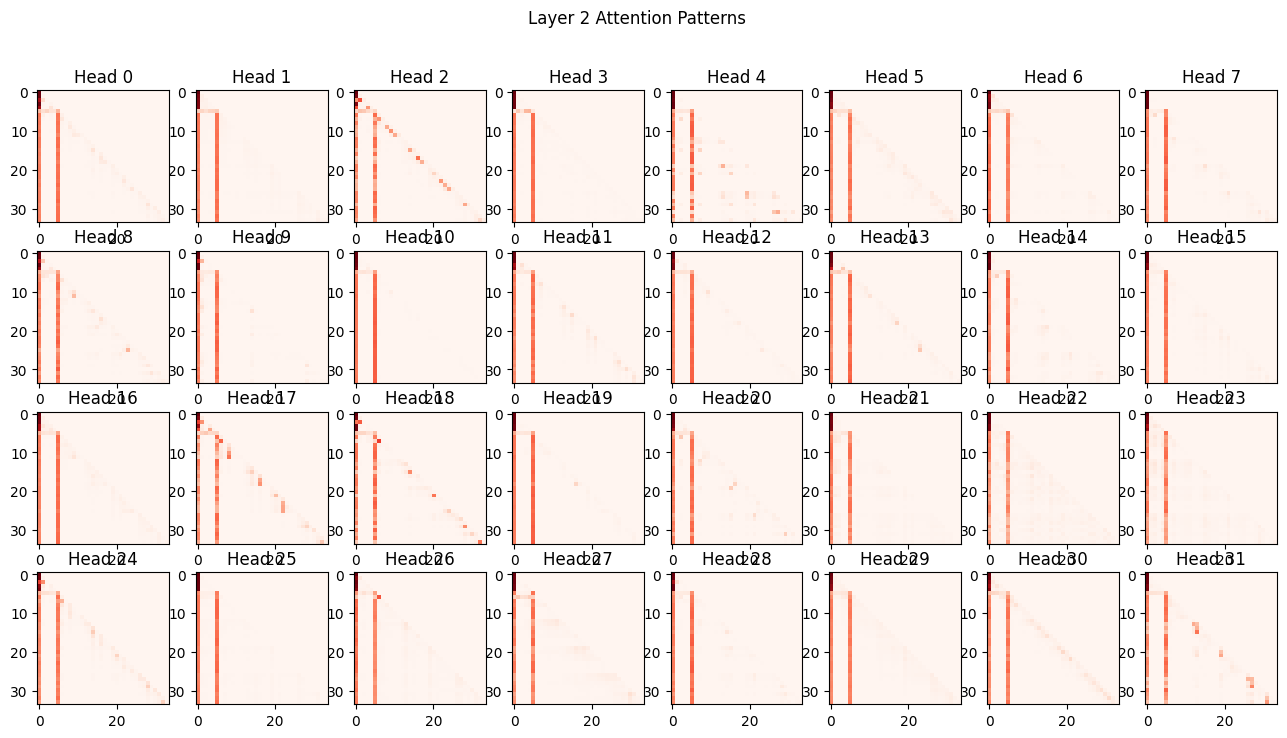

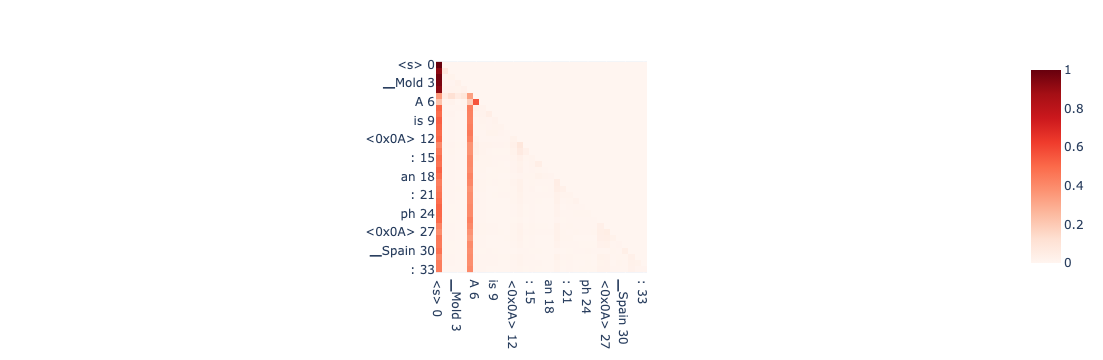

In [11]:
# single attn pattern accross all heads, and a specific head
from src.utils.extract_utils import get_mean_attention_patterns
from src.utils.plot_utils import imshow

layer_idx = 2
head_idx = 26

# single attn pattern
patterns = cache["pattern", layer_idx, "attn"].cpu()

fig, axs = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
# loop through each attention head and plot the attention pattern
for i, ax in enumerate(axs.flatten()):
    ax.imshow(patterns[i], cmap="Reds")
    ax.set_title(f"Head {i}")
plt.suptitle(f"Layer {layer_idx} Attention Patterns")
plt.show()

px.imshow(
    np.array(patterns[head_idx]), 
    color_continuous_scale='Reds',
    y=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
)

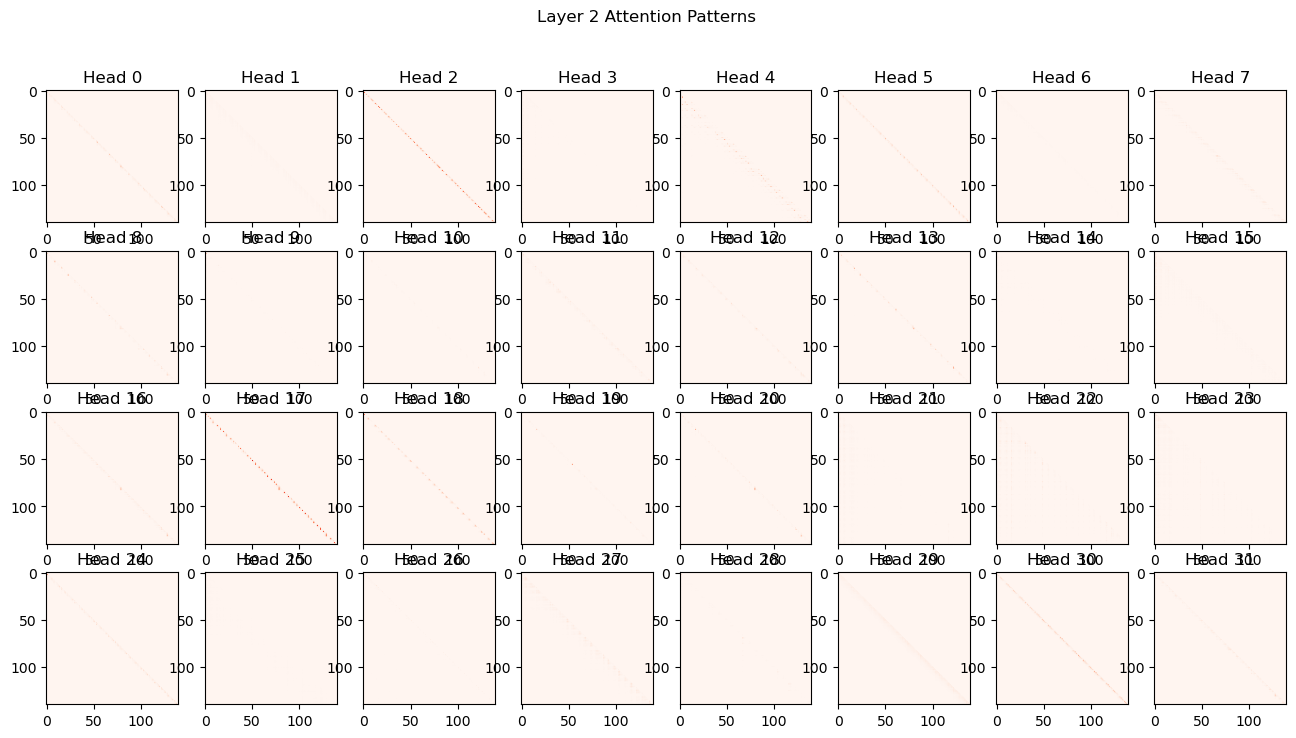

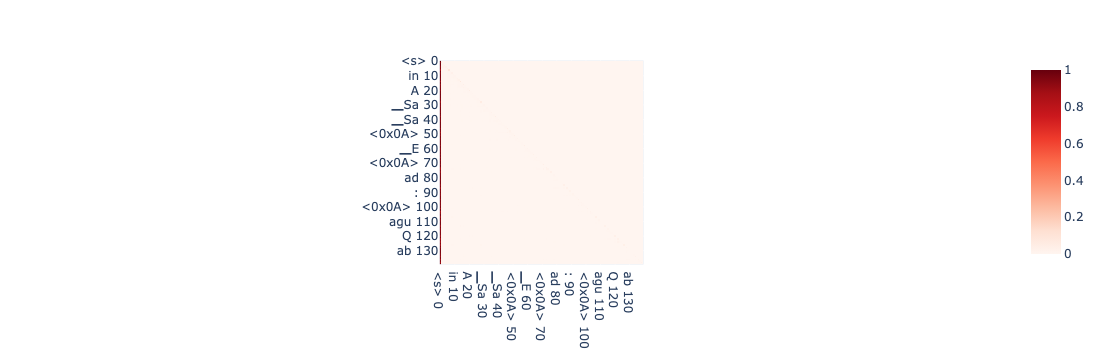

In [120]:
# single attn pattern
patterns = purturb_cache["pattern", layer_idx, "attn"].cpu()

fig, axs = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
# loop through each attention head and plot the attention pattern
for i, ax in enumerate(axs.flatten()):
    ax.imshow(patterns[i], cmap="Reds")
    ax.set_title(f"Head {i}")
plt.suptitle(f"Layer {layer_idx} Attention Patterns")
plt.show()

px.imshow(
    np.array(patterns[head_idx]), 
    color_continuous_scale='Reds',
    y=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
)

### general head pattern

str_tokens: ['<s>', '▁Q', ':', '▁Mold', 'ova', '<0x0A>', 'A', ':', '▁Ch', 'is', 'in', 'au', '<0x0A>', '<0x0A>', 'Q', ':', '▁Bh', 'ut', 'an', '<0x0A>', 'A', ':', '▁Th', 'im', 'ph', 'u', '<0x0A>', '<0x0A>', 'Q', ':', '▁Spain', '<0x0A>', 'A', ':']


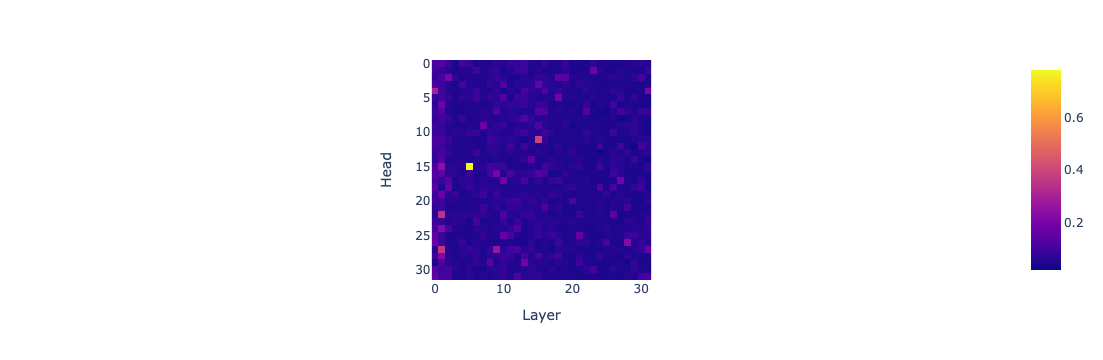

In [51]:
# find heads in all layers all head according to a given pattern
from transformer_lens.head_detector import detect_head
print("str_tokens:", str_tokens)

# previous_token_head, duplicate_token_head, induction_head, care_nothing_head, focus_myself_head, specific_token_head
head_type = "previous_token_head"
token_index = ([12,13,19,26,27,37,44,45,49]) # index of \n
token_index = ([1,6,14,20,28,38,46,50], [1,6,14,20,28,38,46,50])  # index of QA
token_index = [(20, 14), (38, 28)]
token_index = ([-1], [-2])
token_index = -4

if head_type == "specific_token_head":
    orig_attention_score = detect_head(hook_model, tokens, head_type, cache=cache, token_index=token_index)
else:
    orig_attention_score = detect_head(hook_model, tokens, head_type, cache=cache)

px.imshow(
    orig_attention_score.T.float(),
    labels=dict(x="Layer", y="Head"),
)

### suppress head output according to threshold

In [70]:
threshold_success = 0.12
suppr_head_idx_success = torch.argwhere(orig_attention_score > threshold_success).tolist()
threshold_fail = 0.11
suppr_head_idx_fail = torch.argwhere(orig_attention_score > threshold_fail).tolist()

# find the head that exist in fail but not in success
for i in range(len(suppr_head_idx_fail)):
    if suppr_head_idx_fail[i] not in suppr_head_idx_success:
        print("head:", suppr_head_idx_fail[i])

head: [0, 3]
head: [0, 5]
head: [0, 27]
head: [0, 30]
head: [1, 15]
head: [1, 22]
head: [1, 27]
head: [2, 4]
head: [2, 31]
head: [17, 17]
head: [18, 25]
head: [22, 1]
head: [23, 5]
head: [23, 27]
head: [27, 7]
head: [27, 15]
head: [27, 25]
head: [29, 15]
head: [29, 23]
head: [31, 4]


33
model output token  tensor(9669, device='cuda:0')
model output str:  Madrid
target token:  9669
target str:  Madrid
Layer 0 | output prob: 0.0594 | output meaning: пута | pred prob: 0.0000 | rank: 17475
Layer 1 | output prob: 0.0130 | output meaning: tap | pred prob: 0.0000 | rank: 24896
Layer 2 | output prob: 0.0114 | output meaning: tap | pred prob: 0.0000 | rank: 18753
Layer 3 | output prob: 0.0149 | output meaning: Begriffe | pred prob: 0.0000 | rank: 16178
Layer 4 | output prob: 0.0234 | output meaning: Begriffe | pred prob: 0.0000 | rank: 19071
Layer 5 | output prob: 0.0092 | output meaning: UES | pred prob: 0.0000 | rank: 10804
Layer 6 | output prob: 0.0104 | output meaning: arie | pred prob: 0.0000 | rank: 10235
Layer 7 | output prob: 0.0294 | output meaning: Bedeut | pred prob: 0.0000 | rank: 10838
Layer 8 | output prob: 0.0097 | output meaning: arie | pred prob: 0.0000 | rank: 7445
Layer 9 | output prob: 0.0116 | output meaning: Bedeut | pred prob: 0.0000 | rank: 8127
Laye

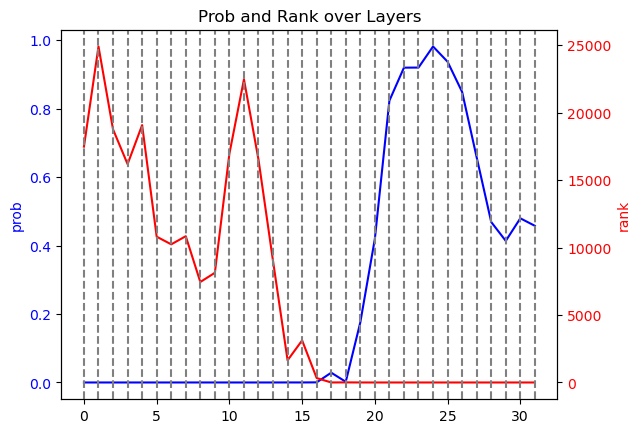

In [34]:
threshold = 0.12
suppr_head_idx = torch.argwhere(orig_attention_score > threshold)
print(len(suppr_head_idx))

from src.utils.hook_utils import *
from src.utils.extract_utils import get_prediction_per_layer

hook_model.reset_hooks()
logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)

ref_pattern = torch.zeros(num_tokens, num_tokens)
ref_pattern = torch.tril(ref_pattern.fill_diagonal_(0.0))

hook_logits = hook_model.run_with_hooks(
    tokens,
    fwd_hooks=\
        # [(utils.get_act_name("pattern", idx[0]), partial(head_pattern_replace_hook, layer_head_idx=idx, ref_pattern=cache["pattern", idx[0], "attn"][idx[1]])) for idx in diff_head_idx],
        [(utils.get_act_name("pattern", idx[0]), partial(head_pattern_replace_hook, layer_head_idx=idx, ref_pattern=ref_pattern)) for idx in suppr_head_idx],
    reset_hooks_end=False,
)
# short_hook_logits, short_hook_cache = hook_model.run_with_cache(short_tokens, remove_batch_dim=True)  # if not run this, hooks may stay
hook_cache = get_prediction_per_layer(hook_model, tokens, target=tgt_token, pos_idx=-1, tokenizer=tokenizer, is_plot=True, return_cache=True)
hook_model.reset_hooks()

### difference in each head

100%|██████████| 32/32 [00:00<00:00, 476.22it/s]


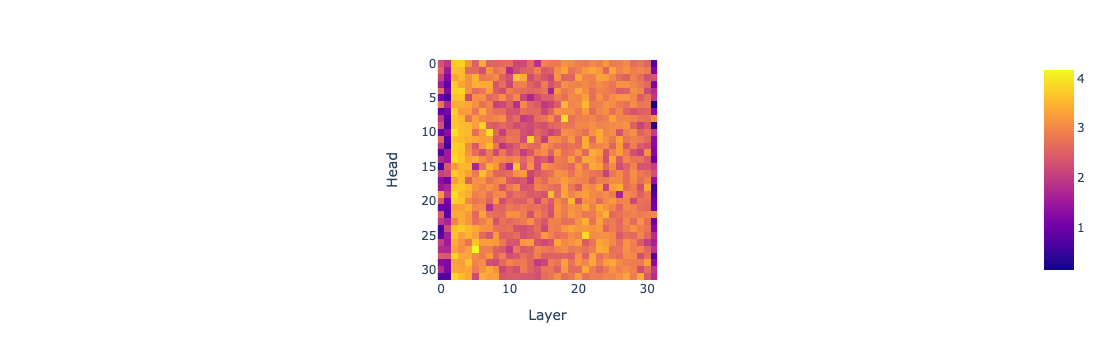

In [13]:
from tqdm import tqdm
head_difference = torch.zeros(hook_model.cfg.n_heads, hook_model.cfg.n_layers)
for layer in tqdm(range(hook_model.cfg.n_layers)):
    for head in range(hook_model.cfg.n_heads):
        head_difference[head][layer] = torch.norm(cache["pattern", layer, "attn"][head] - purturb_cache["pattern", layer, "attn"][head])

px.imshow(
    head_difference.float(),
    labels=dict(x="Layer", y="Head"),
)

### difference in general head patterns

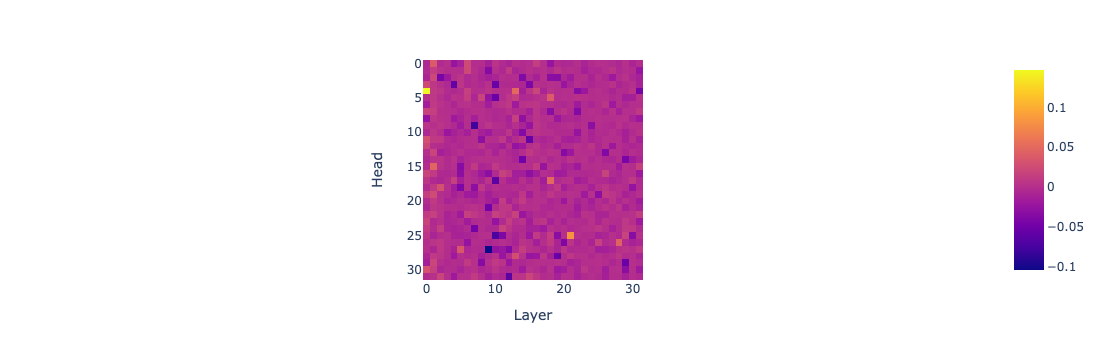

In [52]:
# for short prompt and long prompt (the correct one), find the difference in attention score
# short_attention_score = detect_head(hook_model, short_tokens, head_type, cache=short_cache)
purturb_attention_score = detect_head(hook_model, purturb_tokens, head_type, cache=purturb_cache)
# short_attention_score = detect_head(hook_model, short_tokens, head_type, cache=short_cache, token_index=token_index)

px.imshow(
    orig_attention_score.T.float() - purturb_attention_score.T.float(),
    labels=dict(x="Layer", y="Head"),
)

### patch head output based on difference

20
model output token  tensor(14183, device='cuda:1')
model output str:  nine
target token:  14183
target str:  nine
Layer 0 | output prob: 0.1587 | output meaning: Portail | pred prob: 0.0000 | rank: 3255
Layer 1 | output prob: 0.0175 | output meaning: Portail | pred prob: 0.0001 | rank: 2702
Layer 2 | output prob: 0.0132 | output meaning: Gilbert | pred prob: 0.0000 | rank: 21908
Layer 3 | output prob: 0.0124 | output meaning: occupation | pred prob: 0.0000 | rank: 20308
Layer 4 | output prob: 0.0118 | output meaning: accomp | pred prob: 0.0000 | rank: 21854
Layer 5 | output prob: 0.0139 | output meaning: animate | pred prob: 0.0000 | rank: 20960
Layer 6 | output prob: 0.0121 | output meaning: ers | pred prob: 0.0000 | rank: 10305
Layer 7 | output prob: 0.0138 | output meaning: ﹕ | pred prob: 0.0000 | rank: 14671
Layer 8 | output prob: 0.0140 | output meaning: Kin | pred prob: 0.0000 | rank: 9635
Layer 9 | output prob: 0.0164 | output meaning: живело | pred prob: 0.0000 | rank: 11260

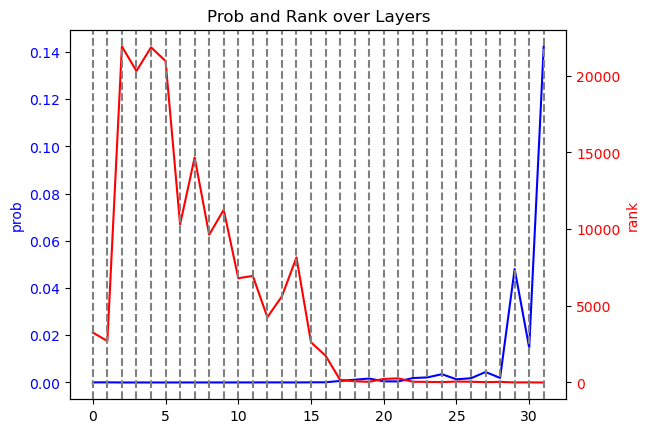

In [33]:
# select the (layer, head) index with difference > 0.038
attention_score_diff = attention_score.float() - short_attention_score.float()
threshold = 0.0
diff_head_idx = torch.argwhere(attention_score_diff > threshold)
print(len(diff_head_idx))

from src.utils.hook_utils import *

# run permanant hook
hook_model.reset_hooks()

logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)

#
ref_pattern = torch.zeros(num_short_tokens, num_short_tokens)
ref_pattern = torch.tril(ref_pattern.fill_diagonal_(0.5))

short_hook_logits = hook_model.run_with_hooks(
    short_tokens,
    fwd_hooks=\
        # [(utils.get_act_name("pattern", idx[0]), partial(head_pattern_replace_hook, layer_head_idx=idx, ref_pattern=cache["pattern", idx[0], "attn"][idx[1]])) for idx in diff_head_idx],
        [(utils.get_act_name("pattern", idx[0]), partial(head_pattern_replace_hook, layer_head_idx=idx, ref_pattern=ref_pattern)) for idx in diff_head_idx],
    reset_hooks_end=False,
)
# short_hook_logits, short_hook_cache = hook_model.run_with_cache(short_tokens, remove_batch_dim=True)  # if not run this, hooks may stay
short_hook_cache = get_prediction_per_layer(hook_model, short_tokens, target=tgt_token, pos_idx=-1, tokenizer=tokenizer, is_plot=True, return_cache=True)
hook_model.reset_hooks()

### head pattern at last position

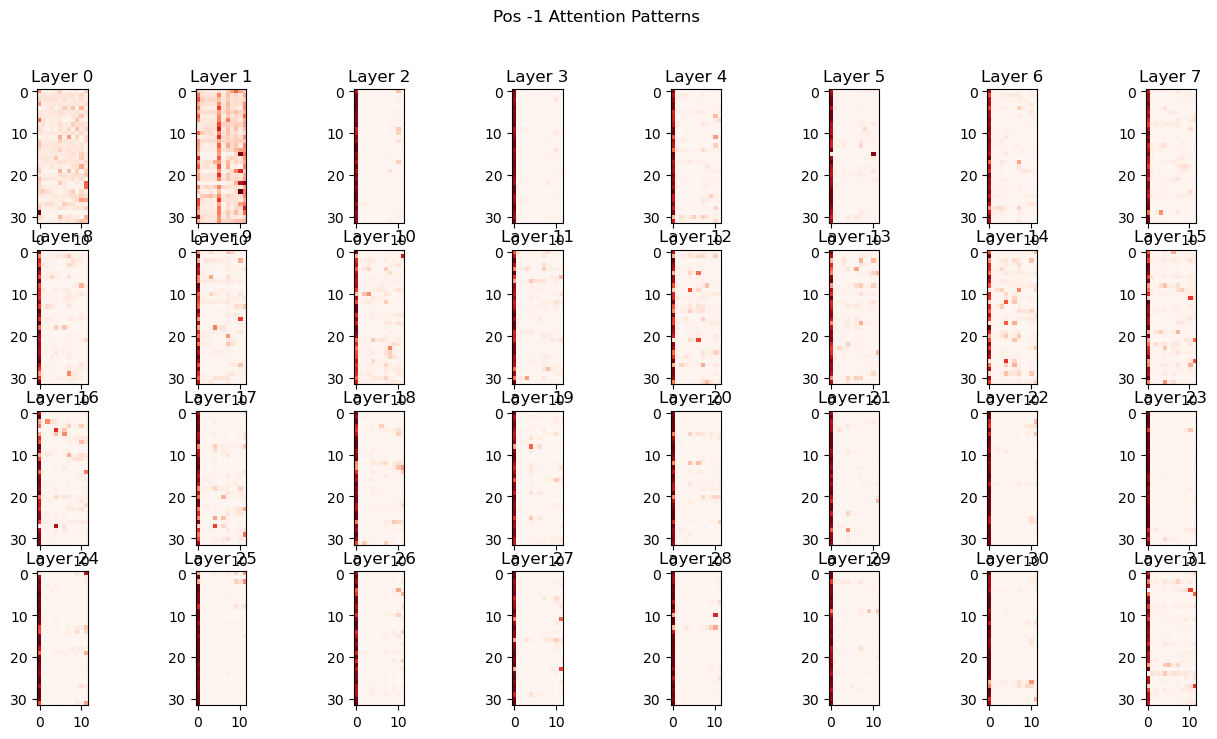

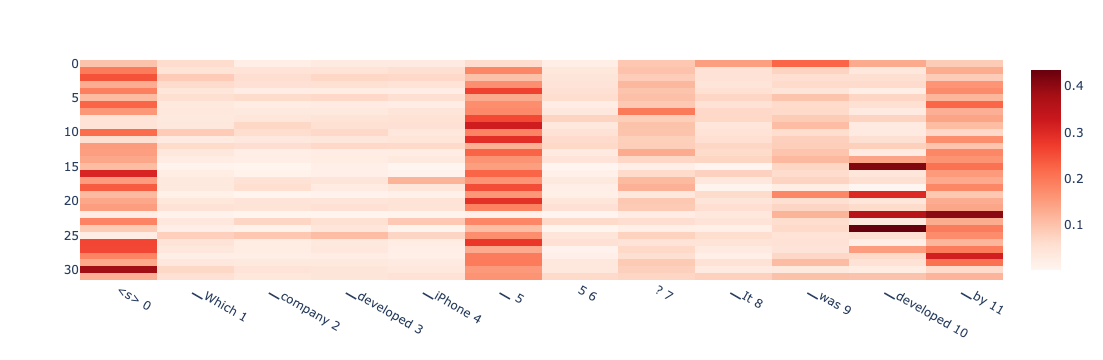

In [12]:
# head attention score (individual and avg) given a single position accross all layers
token_pos = -1
layer_idx = 1

fig, axs = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
# loop through each attention head and plot the attention pattern
for i, ax in enumerate(axs.flatten()):
    ax.imshow(cache["pattern", i, "attn"][:, token_pos, :].cpu(), cmap="Reds")
    ax.set_title(f"Layer {i}")
plt.suptitle(f"Pos {token_pos} Attention Patterns")
plt.show()

px.imshow(
    np.array(cache["pattern", layer_idx, "attn"][:, token_pos, :].cpu()), 
    color_continuous_scale='Reds',
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
)

### avg attention score at last position

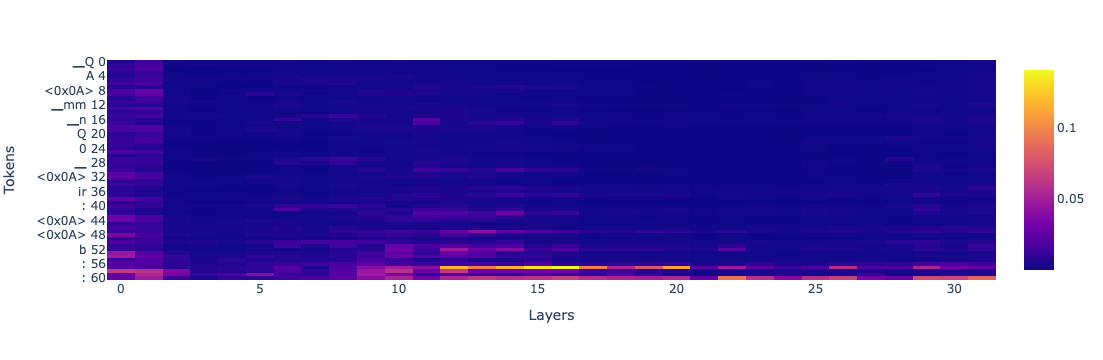

In [111]:
# avg attention score accross all layers
avg_attn = torch.stack([cache["pattern", i, "attn"][:, token_pos, :].mean(dim=0) for i in range(32)])
# remove 0 and 5 columns
avg_attn = torch.cat([avg_attn[:, 1:5], avg_attn[:, 6:]], dim=1)
modified_str_tokens = str_tokens[1:5] + str_tokens[6:]
px.imshow(
    avg_attn.T.cpu(),
    labels=dict(x="Layers", y="Tokens"),
    y=[f"{tok} {i}" for i, tok in enumerate(modified_str_tokens)],
    # y=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
)

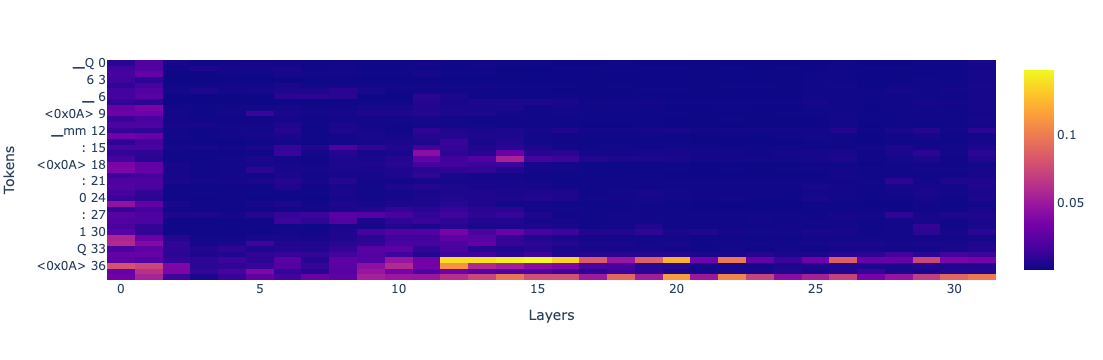

In [35]:
# avg attention score accross all layers
short_avg_attn = torch.stack([short_hook_cache["pattern", i, "attn"][:, token_pos, :].mean(dim=0) for i in range(32)])
# remove 0 and 5 columns
short_avg_attn = torch.cat([short_avg_attn[:, 1:5], short_avg_attn[:, 6:]], dim=1)
modified_short_str_tokens = short_str_tokens[1:5] + short_str_tokens[6:]
px.imshow(
    short_avg_attn.T.cpu(),
    labels=dict(x="Layers", y="Tokens"),
    y=[f"{tok} {i}" for i, tok in enumerate(modified_short_str_tokens)],
    # y=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
)

100%|██████████| 100/100 [00:14<00:00,  7.04it/s]


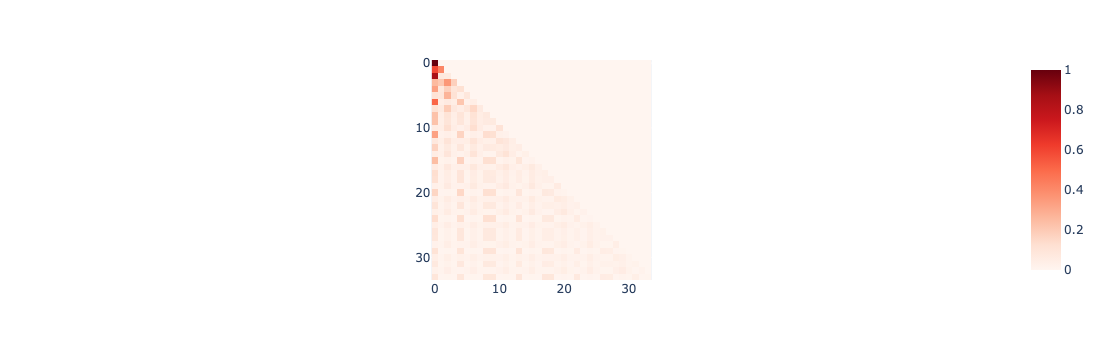

In [26]:
#TODO: mean attn pattern avg over all prompts, that can use in exp
#TODO: make sure that prompts are the same length
mean_patterns = get_mean_attention_patterns(dataset, hook_model, layer_idx=0, head_idx=10, tokenizer=tokenizer)
px.imshow(
    np.array(mean_patterns), 
    color_continuous_scale='Reds',
)

## Semantic meaning of activations

In [43]:
unembed = hook_model.unembed
norm = hook_model.ln_final

# unembed
def unembed_hook_activation(hs, norm=norm, unembed=unembed):
    hs = hs.unsqueeze(0).unsqueeze(0)
    hs = norm(hs)
    logits = unembed(hs).squeeze(0).squeeze(0)
    return logits

def get_topk_logits2vocab(logits, top_k=10, tokenizer=tokenizer):
    probs = torch.softmax(logits, dim=-1)
    top_k_list = torch.topk(probs, k=top_k)
    print([f'{tokenizer.decode(top_k_list.indices[i])}: {top_k_list.values[i]} | ' for i in range(top_k)])


In [45]:
layer_idx = 19
pos_idx = -1

semantic_cache = purturb_cache

resid_pre = semantic_cache[f"blocks.{layer_idx}.hook_resid_pre"][pos_idx]
attn_out = semantic_cache[f"blocks.{layer_idx}.hook_attn_out"][pos_idx]
resid_mid = semantic_cache[f"blocks.{layer_idx}.hook_resid_mid"][pos_idx]
mlp_out = semantic_cache[f"blocks.{layer_idx}.hook_mlp_out"][pos_idx]
resid_post = semantic_cache[f"blocks.{layer_idx}.hook_resid_post"][pos_idx]

get_topk_logits2vocab(unembed_hook_activation(resid_pre))
get_topk_logits2vocab(unembed_hook_activation(attn_out))
get_topk_logits2vocab(unembed_hook_activation(resid_mid))
get_topk_logits2vocab(unembed_hook_activation(mlp_out))
get_topk_logits2vocab(unembed_hook_activation(resid_post))

['subs: 0.033935546875 | ', 'amsung: 0.020751953125 | ', 'firm: 0.01141357421875 | ', 'combining: 0.0095367431640625 | ', 'manufact: 0.00797271728515625 | ', 'apps: 0.0078125 | ', 'android: 0.0078125 | ', 'ren: 0.007312774658203125 | ', 'компа: 0.006206512451171875 | ', '"?>: 0.00615692138671875 | ']
['Japanese: 0.595703125 | ', 'Japan: 0.22607421875 | ', 'Tokyo: 0.07110595703125 | ', 'Japon: 0.0171661376953125 | ', 'jap: 0.0168914794921875 | ', 'japon: 0.014678955078125 | ', 'Korean: 0.01378631591796875 | ', 'galax: 0.0040130615234375 | ', 'Korea: 0.002002716064453125 | ', '☆: 0.001659393310546875 | ']
['amsung: 0.02691650390625 | ', 'Korean: 0.024139404296875 | ', 'subs: 0.018646240234375 | ', 'galax: 0.01306915283203125 | ', 'manufact: 0.011138916015625 | ', 'Sony: 0.0102996826171875 | ', 'Gal: 0.00884246826171875 | ', 'firm: 0.00765228271484375 | ', 'combining: 0.007190704345703125 | ', 'successor: 0.006008148193359375 | ']
['тика: 0.02410888671875 | ', '○: 0.02374267578125 | ', 'a

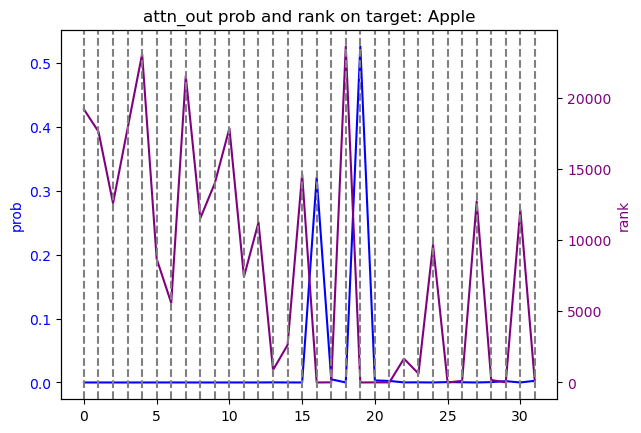

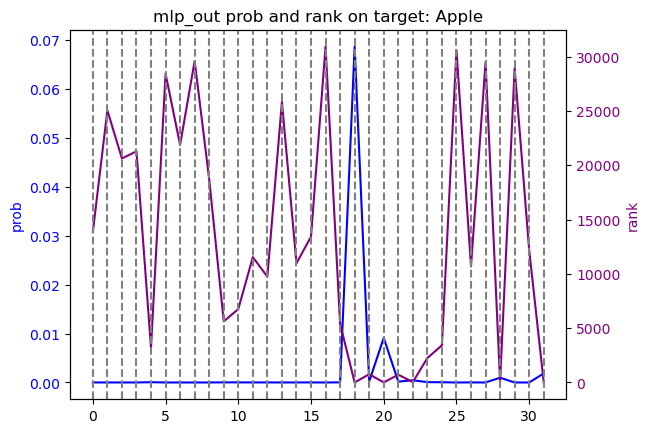

In [46]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import line
from transformer_lens.utils import get_act_name
def get_target_prob_accross_layers(cache, hook_name, target, tokenizer=tokenizer, is_plot=True):
    target_token = tokenizer.encode(target)[1]
    target_probs = []
    target_ranks = []
    for l in range(32):
        if "ln" in hook_name:
            name = get_act_name("normalized", l, hook_name)
        else:
            name = get_act_name(hook_name, l)
        # print(name)
        hs = cache[name][pos_idx]
        proj = unembed_hook_activation(hs)
        prob = torch.softmax(proj, dim=-1)
        target_probs.append(prob[target_token].item())
        target_ranks.append(torch.argsort(prob, descending=True).tolist().index(target_token))
    if is_plot:
        fig, ax1 = plt.subplots()
        ax1.plot(target_probs, color="blue")
        ax1.set_ylabel("prob", color="blue")
        ax1.tick_params(axis="y", labelcolor="blue")

        ax2 = ax1.twinx()
        ax2.plot(target_ranks, color="purple")
        ax2.set_ylabel("rank", color="purple")
        ax2.tick_params(axis="y", labelcolor="purple")

        for i in range(len(target_probs)):
            plt.axvline(x=i, color="grey", linestyle="--")
        plt.title(f"{hook_name} prob and rank on target: {target}")
        plt.show()
    else: 
        return target_probs

# get_target_prob_accross_layers(cache, hook_name="ln2", target="wall")
get_target_prob_accross_layers(cache, hook_name="attn_out", target="Apple")
get_target_prob_accross_layers(cache, hook_name="mlp_out", target="Apple")
# get_target_prob_accross_layers(cache, hook_name="resid_post", target="wall")

### suppress output at critical layers

In [15]:
from src.utils.hook_utils import *

hook_model.reset_hooks()
logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)

hook = partial(residual_stream_zeroing_hook, position=-1)

hook_logits = hook_model.run_with_hooks(
    tokens,
    fwd_hooks=[\
        (utils.get_act_name("mlp_out", 26), hook),
        (utils.get_act_name("mlp_out", 24), hook),
        (utils.get_act_name("mlp_out", 23), hook),
        (utils.get_act_name("mlp_out", 18), hook),
        (utils.get_act_name("attn_out", 28), hook),
    ],
    reset_hooks_end=False,
)

hook_cache = get_prediction_per_layer(hook_model, tokens, target=tgt_token, pos_idx=-1, tokenizer=tokenizer, is_plot=False, return_cache=True)
hook_model.reset_hooks()

model output token  tensor(830, device='cuda:0')
model output str:  Re
target token:  830
target str:  Re
Layer 0 | output prob: 0.2024 | output meaning: Portail | pred prob: 0.0000 | rank: 26847
Layer 1 | output prob: 0.0267 | output meaning: sterd | pred prob: 0.0000 | rank: 26303
Layer 2 | output prob: 0.0134 | output meaning: daten | pred prob: 0.0000 | rank: 29031
Layer 3 | output prob: 0.0242 | output meaning: gresql | pred prob: 0.0000 | rank: 29081
Layer 4 | output prob: 0.0210 | output meaning: ping | pred prob: 0.0000 | rank: 28543
Layer 5 | output prob: 0.0277 | output meaning: gresql | pred prob: 0.0000 | rank: 24755
Layer 6 | output prob: 0.0236 | output meaning: yes | pred prob: 0.0000 | rank: 27109
Layer 7 | output prob: 0.0411 | output meaning: yes | pred prob: 0.0000 | rank: 19352
Layer 8 | output prob: 0.0133 | output meaning: none | pred prob: 0.0000 | rank: 16499
Layer 9 | output prob: 0.0325 | output meaning: none | pred prob: 0.0000 | rank: 20241
Layer 10 | output

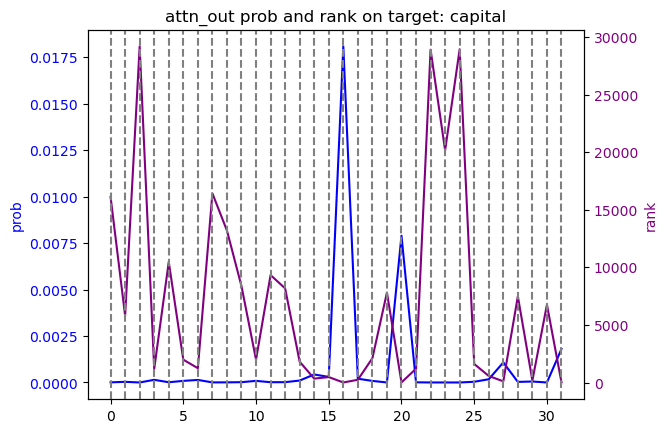

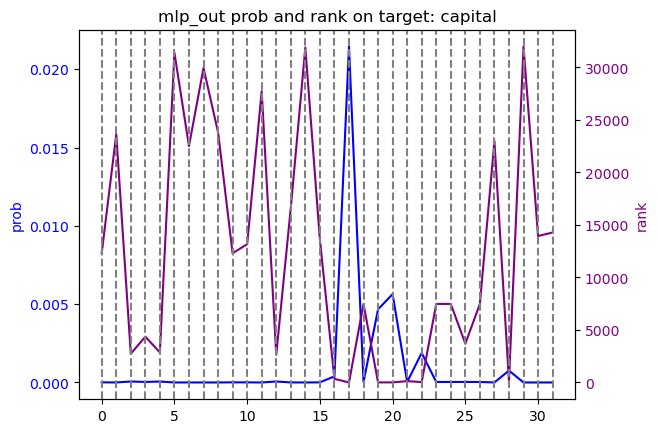

In [16]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import line
from transformer_lens.utils import get_act_name
pos_idx = -1

def get_target_prob_accross_layers(cache, hook_name, target, tokenizer=tokenizer, is_plot=True):
    target_token = tokenizer.encode(target)[1]
    target_probs = []
    target_ranks = []
    for l in range(32):
        if "ln" in hook_name:
            name = get_act_name("normalized", l, hook_name)
        else:
            name = get_act_name(hook_name, l)
        # print(name)
        hs = cache[name][pos_idx]
        proj = unembed_hook_activation(hs)
        prob = torch.softmax(proj, dim=-1)
        target_probs.append(prob[target_token].item())
        target_ranks.append(torch.argsort(prob, descending=True).tolist().index(target_token))
    if is_plot:
        fig, ax1 = plt.subplots()
        ax1.plot(target_probs, color="blue")
        ax1.set_ylabel("prob", color="blue")
        ax1.tick_params(axis="y", labelcolor="blue")

        ax2 = ax1.twinx()
        ax2.plot(target_ranks, color="purple")
        ax2.set_ylabel("rank", color="purple")
        ax2.tick_params(axis="y", labelcolor="purple")

        for i in range(len(target_probs)):
            plt.axvline(x=i, color="grey", linestyle="--")
        plt.title(f"{hook_name} prob and rank on target: {target}")
        plt.show()
    else: 
        return target_probs

# get_target_prob_accross_layers(cache, hook_name="ln2", target="wall")
get_target_prob_accross_layers(hook_cache, hook_name="attn_out", target="capital")
get_target_prob_accross_layers(hook_cache, hook_name="mlp_out", target="capital")
# get_target_prob_accross_layers(cache, hook_name="resid_post", target="wall")

## Intervention: local and global attentions

## Zeroing out model components

### zeoring out single module, long prompt

In [92]:
from src.utils.hook_utils import *
from tqdm import tqdm

logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)
assert logits[:, -1].argmax() == tgt_token

attn_to_mlp_prob_diffs = torch.zeros((hook_model.cfg.n_layers, num_tokens))
attn_to_resid_prob_diffs = torch.zeros((hook_model.cfg.n_layers, num_tokens))
mlp_to_resid_prob_diffs = torch.zeros((hook_model.cfg.n_layers, num_tokens))
attn_mlp_to_resid_prob_diffs = torch.zeros((hook_model.cfg.n_layers, num_tokens))

hook_model.reset_hooks()
for layer in tqdm(range(hook_model.cfg.n_layers)):
    for position in range(num_tokens):
        
        # hooks
        resid_zeroing = partial(residual_stream_zeroing_hook, position=position)
        attn_out_adding = partial(
            attn_out_hook, position=position, 
            attn_out=cache[f"blocks.{layer}.hook_attn_out"][position], add_back=True
        )
        attn_out_zeroing = partial(
            attn_out_hook, position=position, 
            attn_out=cache[f"blocks.{layer}.hook_attn_out"][position]
        )

        # attn out to mlp
        attn_to_mlp_logits = hook_model.run_with_hooks(tokens, fwd_hooks=[
            (utils.get_act_name("resid_mid", layer), attn_out_zeroing),
            (utils.get_act_name("resid_post", layer), attn_out_adding), 
        ])

        # attn out to resid
        attn_to_resid_logits = hook_model.run_with_hooks(tokens, fwd_hooks=[
            (utils.get_act_name("resid_post", layer), attn_out_zeroing),
        ])

        # mlp to resid
        mlp_to_resid_logits = hook_model.run_with_hooks(tokens, fwd_hooks=[
            (utils.get_act_name("mlp_out", layer), resid_zeroing),
        ])

        # both to resid
        attn_mlp_to_resid_logits = hook_model.run_with_hooks(tokens, fwd_hooks=[
            (utils.get_act_name("attn_out", layer), resid_zeroing),
            (utils.get_act_name("mlp_out", layer), resid_zeroing),
        ])

        attn_to_mlp_prob_diffs[layer, position] = logits_to_logit_diff(logits, attn_to_mlp_logits)[1]
        attn_to_resid_prob_diffs[layer, position] = logits_to_logit_diff(logits, attn_to_resid_logits)[1]
        mlp_to_resid_prob_diffs[layer, position] = logits_to_logit_diff(logits, mlp_to_resid_logits)[1]
        attn_mlp_to_resid_prob_diffs[layer, position] = logits_to_logit_diff(logits, attn_mlp_to_resid_logits)[1]


100%|██████████| 32/32 [08:55<00:00, 16.74s/it]


Q: Moldova
A: Chisinau

Q: Bhutan
A: Thimphu

Q: Sao Tome and Principe
A: Sao Tome

Q: Kosovo
A: Pristina

Q: Eritrea
A: Asmara

Q: Australia
A:


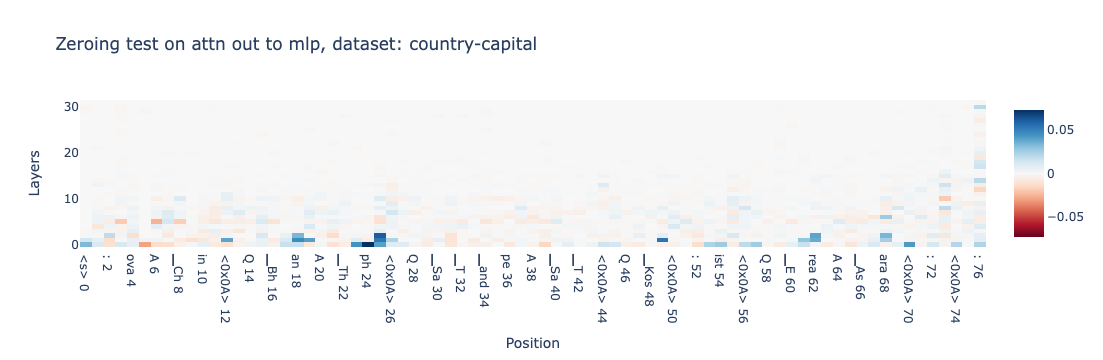

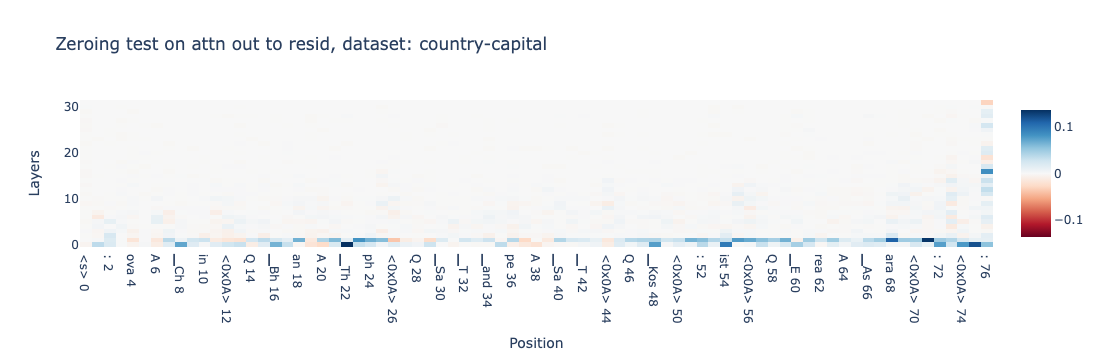

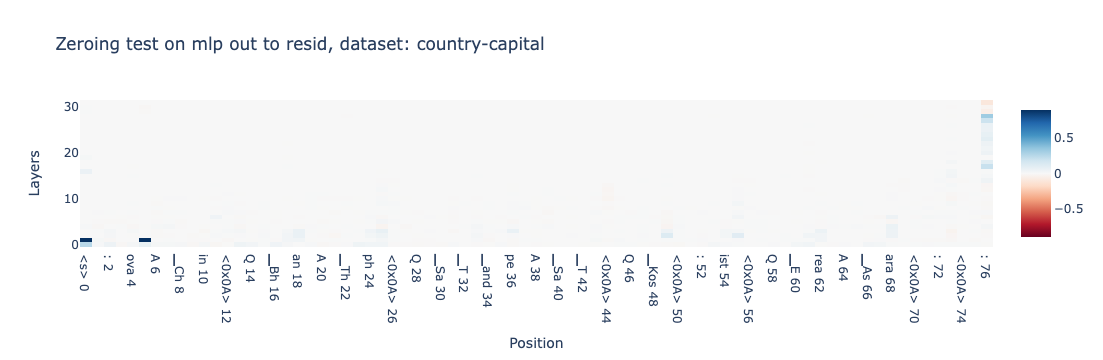

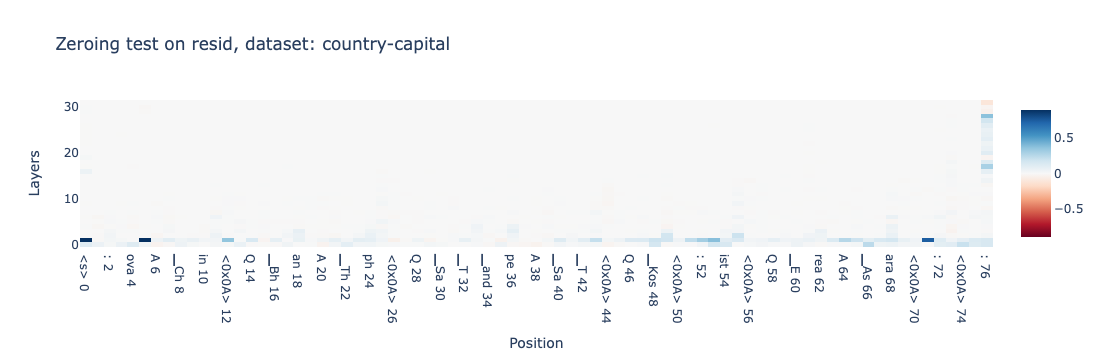

In [71]:
# long icl prompt
from src.utils.plot_utils import *
print(prompt)
imshow_px(
    attn_to_mlp_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on attn out to mlp, dataset: {dataset_name}",
    origin='lower',
)
imshow_px(
    attn_to_resid_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on attn out to resid, dataset: {dataset_name}",
    origin='lower',
)
imshow_px(
    mlp_to_resid_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on mlp out to resid, dataset: {dataset_name}",
    origin='lower',
)
imshow_px(
    attn_mlp_to_resid_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on resid, dataset: {dataset_name}",
    origin='lower',
)

### zeroing out single module, shorter prompt

Q: Moldova
A: Chisinau

Q: Bhutan
A: Thimphu

Q: Australia
A:


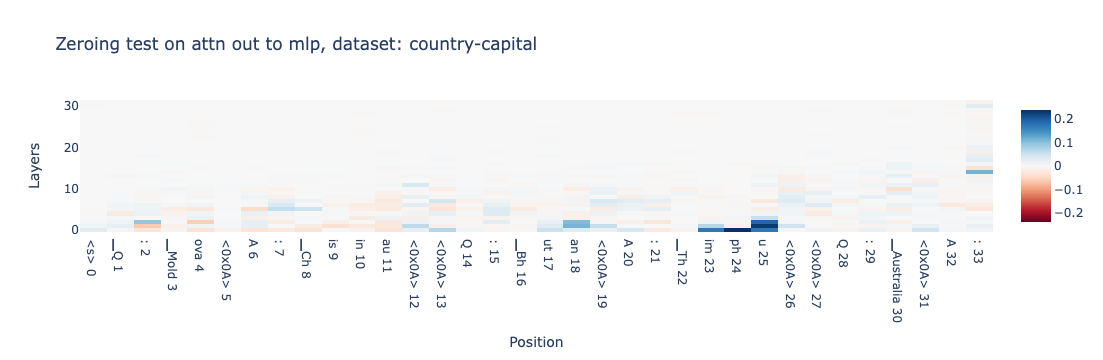

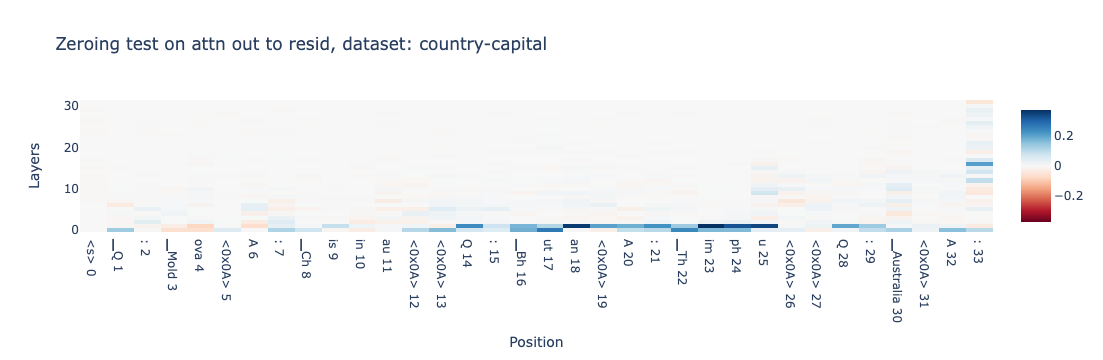

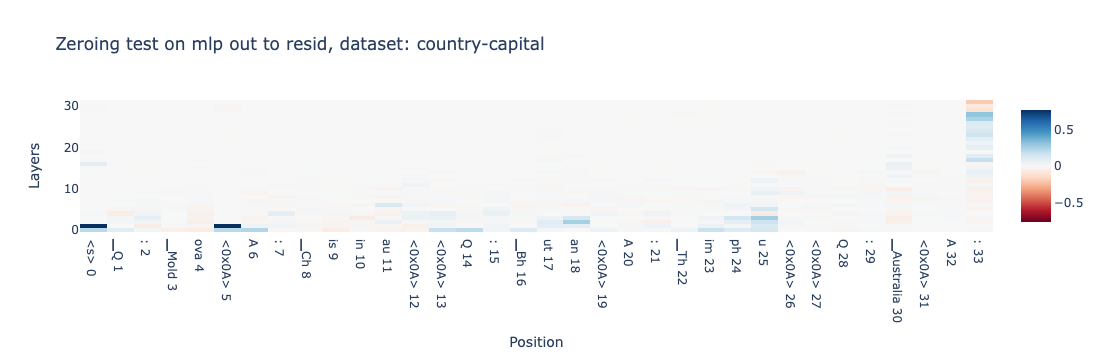

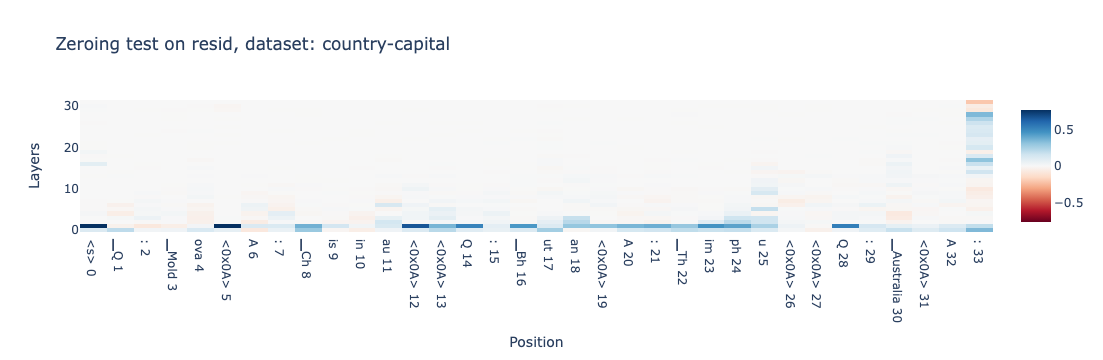

In [93]:
# shorter icl prompt
print(prompt)
imshow_px(
    attn_to_mlp_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on attn out to mlp, dataset: {dataset_name}",
    origin='lower',
)
imshow_px(
    attn_to_resid_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on attn out to resid, dataset: {dataset_name}",
    origin='lower',
)
imshow_px(
    mlp_to_resid_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on mlp out to resid, dataset: {dataset_name}",
    origin='lower',
)
imshow_px(
    attn_mlp_to_resid_prob_diffs,
    xaxis="Position",
    yaxis="Layers",
    x=[f"{tok} {i}" for i, tok in enumerate(str_tokens)],
    title=f"Zeroing test on resid, dataset: {dataset_name}",
    origin='lower',
)

### zeroing out group of modules

model output token  tensor(9669, device='cuda:0')
model output str:  Madrid
target token:  9669
target str:  Madrid
Layer 0 | output prob: 0.1842 | output meaning: Portail | pred prob: 0.0000 | rank: 23442
Layer 1 | output prob: 0.0221 | output meaning: sterd | pred prob: 0.0000 | rank: 23715
Layer 2 | output prob: 0.0130 | output meaning: idense | pred prob: 0.0000 | rank: 16619
Layer 3 | output prob: 0.0152 | output meaning: occupation | pred prob: 0.0000 | rank: 11673
Layer 4 | output prob: 0.0223 | output meaning: ping | pred prob: 0.0000 | rank: 10742
Layer 5 | output prob: 0.0258 | output meaning: gresql | pred prob: 0.0000 | rank: 13321
Layer 6 | output prob: 0.0237 | output meaning: yes | pred prob: 0.0000 | rank: 24627
Layer 7 | output prob: 0.0334 | output meaning: yes | pred prob: 0.0000 | rank: 18564
Layer 8 | output prob: 0.0251 | output meaning: yes | pred prob: 0.0000 | rank: 21863
Layer 9 | output prob: 0.0454 | output meaning: none | pred prob: 0.0000 | rank: 24149
Lay

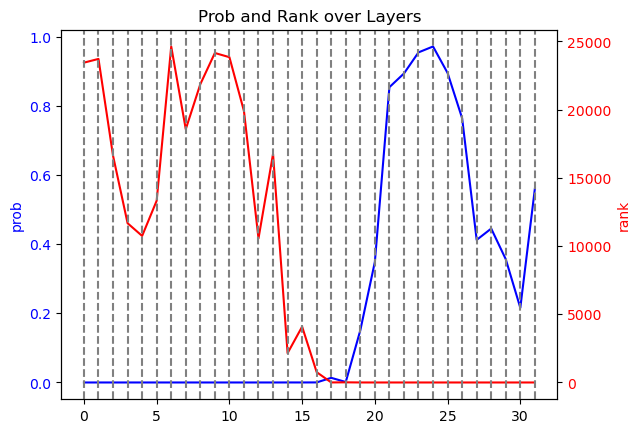

In [60]:
from src.utils.hook_utils import *

hook_model.reset_hooks()
logits, cache = hook_model.run_with_cache(tokens, remove_batch_dim=True)

# range(hook_model.cfg.n_layers)
hook = partial(residual_stream_zeroing_hook, position=[-1])

zero_range_mlp = range(8,9)
zero_range_attn = range(9,10)

hook_logits = hook_model.run_with_hooks(
    tokens,
    fwd_hooks=[\
        (utils.get_act_name("mlp_out", l), hook) for l in zero_range_mlp
    ]+[\
        (utils.get_act_name("attn_out", l), hook) for l in zero_range_attn],
    reset_hooks_end=False,
)

hook_cache = get_prediction_per_layer(hook_model, tokens, target=tgt_token, pos_idx=-1, tokenizer=tokenizer, is_plot=True, return_cache=True)
hook_model.reset_hooks()